# Molecular Dynamics simulation

## TL;DR

- MD simulations follow the equations of motion of classical mechanics, and the time evolution of the positions and velocities of all atoms can be observed.
- The upper limit is generally a few dozen ns due to the time scale limitation. If a phenomenon does not occur within that time, it is necessary to consider a different calculation method.
- In MD simulations, there are various states (ensembles) depending on the state to be reproduced, and the simplest ensemble is called the NVE ensemble.
- In the NVE ensemble, the total energy conservation law holds, and the time step must be set appropriately in terms of calculation accuracy and calculation time.

In this chapter, you will learn about **Molecular dynamics (MD)**, which simulates the time evolution of a system.

MD simulation explicitly deals with the time evolution of the trajectories of individual atoms. It is a method that calculates the coordinates and velocities of the target atoms sequentially by integrating the equations of motion of classical mechanics. 
This calculation method itself is a theory independent of models of forces and energies acting between atoms, and has long been used in the field of molecular simulation.
Therefore, for the theoretical background and examples, please refer to the existing books and references (for example, [1-3]). The purpose of this tutorial is to acquire the **pracitical** knowledge necessary to perform these calculations using Matlantis.

Let's take a look at what can be observed in an MD simulation by running an example.

 - https://wiki.fysik.dtu.dk/ase/tutorials/md/md.html

## Preliminary setup - Installation of required libraries

Through this chapter, we sometimes use ASAP3-EMT, which is a classical force field easily accessible on ASE. Since it is a classical force field, its accuracy and application are limited, but it is so simple and fast that very useful to demonstrate important points in this tutorial without much hustle and frustration. The elements available in ASAP3-EMT are limited to Ni, Cu, Pd, Ag, Pt, Au and their alloys. The installation procedure is as follows.

In [1]:
!pip install --upgrade asap3

Looking in indexes: https://pypi.org/simple, http://pypi.artifact.svc:8080/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 855.8/855.8 kB 65.4 MB/s eta 0:00:00
  Installing build dependencies ... one
  Getting requirements to build wheel ... done
  Installing backend dependencies ... one
  Preparing metadata (pyproject.toml) ... done
done
  Created wheel for asap3: filename=asap3-3.13.7-cp311-cp311-linux_x86_64.whl size=4461488 sha256=8ef68bdc4c47a62e592d5d40598d3921480daf8f34de9a6d3b63d718ff1ec1b7
  Stored in directory: /home/jovyan/.cache/pip/wheels/d1/8c/80/5aa8169f1b9773bb685620a4ce577adcd238f95b106ce06013
Successfully built asap3

[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


For details about ASAP3-EMT, please refer [ASAP official page](https://wiki.fysik.dtu.dk/asap/asap).

## What can MD simulation do?

In the following example, the MD simulation reproduces the molten state of a metallic Al structure. As everyone knows, aluminum is one of the most common metal in both commertial and industrial sectors. 
Its properties are well known. It has a melting point of 660.3 °C (933.45 K) and the face-centered cubic (fcc) phase is stable over a wide temperature range under ambient pressure. 
The following shows the process of melting the fcc-Al structure by heating it to an initial temperature of 1600 K. The calculation time is 100 psec.

</br>
<figure style="text-align:center">
  <img src="../assets/ch6/Fig6-1_fcc-Al_NVE_1600Kstart.png" alt="fcc-Al_NVE_1600Kstart">
  <figcaption>Fig6-1a. Melting of fcc-Al in NVE ensemble starting at 1600 K</figcaption>
  <figcaption>         (File: ../input/ch6/6-1_fcc-Al_NVE_1600Kstart.traj)</figcaption>
</figure>

The Al atoms are initially arranged in a clean fcc crystal structure, but the structure is gradually disrupted and the atoms gradually diffuse out of the simulation cell as the calculation proceeds. 
In this way, **MD simulations allow us to observe in detail the actual trajectories of the atoms as they evolve over time**.

## Simulation of aluminum melting

Below is a sample code of the MD simulation used to reproduce the melting process of fcc-Al described above. 
The ASAP3 EMT force field is used to speed up the calculation. (To use this force field in your python environment, you must first install the asap3 package by running `pip install asap3`.) 
The following calculation runs for 100 psec MD and takes only a few tens of seconds to complete.

In [2]:
%%time
import os
from asap3 import EMT
calculator = EMT()

from ase.build import bulk
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution,Stationary
from ase.md.verlet import VelocityVerlet
from ase.md import MDLogger
from ase import units
from time import perf_counter
import numpy as np

# Set up a fcc-Al crystal
atoms = bulk("Al","fcc",a=4.3,cubic=True)
atoms.pbc = True
atoms *= 3
print("atoms = ",atoms)

# Set calculator (EMT in this case)
atoms.calc = calculator

# input parameters
time_step    = 1.0      # MD step size in fsec
temperature  = 1600     # Temperature in Kelvin
num_md_steps = 100000   # Total number of MD steps
num_interval = 1000     # Print out interval for .log and .traj

# Set the momenta corresponding to the given "temperature"
MaxwellBoltzmannDistribution(atoms, temperature_K=temperature,force_temp=True)
Stationary(atoms)  # Set zero total momentum to avoid drifting

# Set output filenames
output_filename = "./output/ch6/liquid-Al_NVE_1.0fs_test"
log_filename = output_filename + ".log"
print("log_filename = ",log_filename)
traj_filename = output_filename + ".traj"
print("traj_filename = ",traj_filename)

# Remove old files if they exist
if os.path.exists(log_filename): os.remove(log_filename)
if os.path.exists(traj_filename): os.remove(traj_filename)

# Define the MD dynamics class object
dyn = VelocityVerlet(atoms, 
                     time_step * units.fs,
                     trajectory = traj_filename,
                     loginterval=num_interval
                    )  

# Print statements
def print_dyn():
    imd = dyn.get_number_of_steps()
    time_md = time_step*imd
    etot  = atoms.get_total_energy()
    ekin  = atoms.get_kinetic_energy()
    epot  = atoms.get_potential_energy()
    temp_K = atoms.get_temperature()
    print(f"   {imd: >3}     {etot:.9f}     {ekin:.9f}    {epot:.9f}   {temp_K:.2f}")

dyn.attach(print_dyn, interval=num_interval)

# Set MD logger
dyn.attach(MDLogger(dyn, atoms, log_filename, header=True, stress=False,peratom=False, mode="w"), interval=num_interval)

# Now run MD simulation
print(f"\n    imd     Etot(eV)    Ekin(eV)    Epot(eV)    T(K)")
dyn.run(num_md_steps)

print("\nNormal termination of the MD run!")

atoms =  Atoms(symbols='Al108', pbc=True, cell=[12.899999999999999, 12.899999999999999, 12.899999999999999])
log_filename =  ./output/ch6/liquid-Al_NVE_1.0fs_test.log
traj_filename =  ./output/ch6/liquid-Al_NVE_1.0fs_test.traj

    imd     Etot(eV)    Ekin(eV)    Epot(eV)    T(K)
     0     32.139701294     22.336120234    9.803581060   1600.00
   1000     32.144722159     9.393665122    22.751057037   672.90
   2000     32.144501700     10.379779872    21.764721828   743.53
   3000     32.144318649     10.246193775    21.898124875   733.96
   4000     32.144092145     11.057828314    21.086263831   792.10
   5000     32.144046250     11.951114265    20.192931985   856.09
   6000     32.144260378     10.923214025    21.221046353   782.46
   7000     32.144403860     10.881528388    21.262875472   779.47
   8000     32.144603170     10.966654516    21.177948654   785.57
   9000     32.144375218     11.119079419    21.025295799   796.49
   10000     32.144222322     11.189498687    20.95

The flow of the program can be understood by looking at the comments in the script, but the important points are explained here.

（１） Initial velocity distribution

Once the structure has been created and the calculation parameters have been set, the initial velocity of each atom is given by a velocity distribution corresponding to the specified temperature [Maxwell-Boltzmann distribution](https://en.wikipedia.org/wiki/Maxwell%E2%80%93Boltzmann_distribution).
This is done using the `MaxwellBoltzmannDistribution` in above code. 
Since the initial velocity given by this method has arbitrary momentum of the whole system, there is a possibility that the whole system may drift. 
Therefore, after giving the initial velocity by `MaxwellBoltzmannDistribution`, we set the momentum of the entire system to zero by the `Stationary` method and fix the coordinates of the center of mass.
This is important not only for the NVE case, but also for simulations involving temperature and pressure control that will follow.

（２） Execute MD

This time, MD by [Verlet integration](https://en.wikipedia.org/wiki/Verlet_integration) is executed using the class `VelocityVerlet`.
MD is actually executed at `dyn.run(num_md_steps)`.
In this time, `time_step=1.0` (time width of 1fs = $1 \times 10^{-15}$ sec per step) is used to execute `num_md_steps=100000` steps.

（3） Recording of calculation results

The script has a method named `print_dyn` that prints energy and temperature values to standard output (output on a notebook).
There is another class, `MDLogger`, which outputs energy, temperature, and stress information in a specified log file.
You can define your own class to output the calculation results to a file, but the default logger provides the necessary information for most applications, so it is recommended to utilize it.

After MD is executed, the trajectory can be visualized as follows.

In [3]:
from ase.io import Trajectory
from pfcc_extras.visualize.view import view_ngl


traj = Trajectory(traj_filename)
view_ngl(traj)

In [4]:
from pfcc_extras.visualize.povray import traj_to_apng
from IPython.display import Image


traj_to_apng(traj, f"output/Fig6-1_fcc-Al_NVE_1600Kstart.png", rotation="0x,0y,0z", clean=True, n_jobs=16)

# See Fig6-1a
#Image(url="output/Fig6-1_fcc-Al_NVE_1600Kstart.png")

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:   12.8s
[Parallel(n_jobs=16)]: Done 101 out of 101 | elapsed:   41.7s finished


## History of physical properties in NVE ensembles

Since the velocity (i.e., momentum) of each atom is known, the history of the various energies of the system can be followed. 
For example, here are the time profiles of total energy (Tot.E.), potential energy (P.E.), kinetic energy (K.E.), and temperature (Temp.) for the melting of fcc-Al.

In [5]:
import pandas as pd

df = pd.read_csv(log_filename, delim_whitespace=True)
df

/tmp/ipykernel_50921/510401485.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(log_filename, delim_whitespace=True)


,Time[ps],Etot[eV],Epot[eV],Ekin[eV],T[K]
0,0.0,32.140,9.804,22.336,1600.0
1,1.0,32.145,22.751,9.394,672.9
2,2.0,32.145,21.765,10.380,743.5
3,3.0,32.144,21.898,10.246,734.0
4,4.0,32.144,21.086,11.058,792.1
...,...,...,...,...,...
96,96.0,32.145,23.855,8.290,593.8
97,97.0,32.145,24.317,7.828,560.7
98,98.0,32.145,23.694,8.451,605.4
99,99.0,32.145,23.513,8.632,618.3


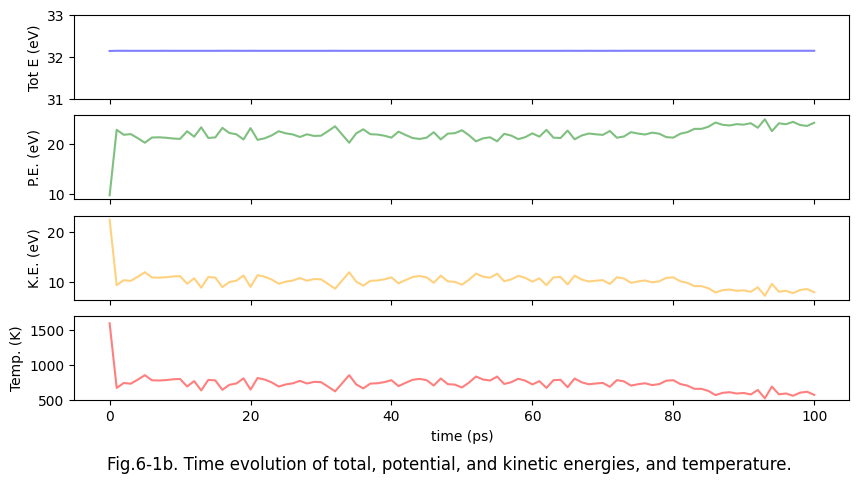

In [6]:
import numpy as np
import matplotlib.pyplot as plt


fig = plt.figure(figsize=(10, 5))

#color = 'tab:grey'
ax1 = fig.add_subplot(4, 1, 1)
ax1.set_xticklabels([])  
ax1.set_ylabel('Tot E (eV)')  
ax1.set_ylim([31.,33.])
ax1.plot(df["Time[ps]"], df["Etot[eV]"], color="blue",alpha=0.5)

ax2 = fig.add_subplot(4, 1, 2)
ax2.set_xticklabels([])  
ax2.set_ylabel('P.E. (eV)')  
ax2.plot(df["Time[ps]"], df["Epot[eV]"], color="green",alpha=0.5)

ax3 = fig.add_subplot(4, 1, 3)
ax3.set_xticklabels([])  
ax3.set_ylabel('K.E. (eV)')  
ax3.plot(df["Time[ps]"], df["Ekin[eV]"], color="orange",alpha=0.5)

ax4 = fig.add_subplot(4, 1, 4)
ax4.set_xlabel('time (ps)')  
ax4.set_ylabel('Temp. (K)')  
ax4.plot(df["Time[ps]"], df["T[K]"], color="red",alpha=0.5)
ax4.set_ylim([500., 1700])

fig.suptitle("Fig.6-1b. Time evolution of total, potential, and kinetic energies, and temperature.", y=0)

#plt.savefig("6-1_liquid-Al_NVE_1.0fs_test_E_vs_t.png")  # <- Use if saving to an image file is desired
plt.show()

As mentioned in section 1-5, the total energy $E$ of a system is expressed by the kinetic energy $K$ and the potential energy $V$.

$$ E = K + V $$

Of these, the kinetic energy $K$ of a system can be calculated as follows, using the formula from classical mechanics.

$$ K = \sum_{i=1}^{N} \frac{1}{2} m_i {\mathbf{v}}_i^2 = \sum_{i=1}^{N} \frac{{\mathbf{p}}_i^2}{2 m_i}  $$

where $m_i, \mathbf{v}_i, \mathbf{p}_i$ are the mass, velocity and momentum ($\mathbf{p}=m\mathbf{v}$) of each atom respectively. 
Here, the temperature and kinetic energy of the system are synonymous and are defined by the following relationship.

$$ K = \frac{3}{2} k_B T$$

In this case, the initial temperature is set to 1600 K, and the system evolves naturally in time according to the equations of motion of classical mechanics. 
Since there is no external force, the energy conservation law is obeyed and the total energy is kept constant within the numerical error. 
The temperature decreases fairly quickly, and the kinetic and potential energies follows the [equipartition theorem](https://en.wikipedia.org/wiki/Equipartition_theorem), and the temperature eventually settles to about half the initial temperature.
This is how matter actually behaves in nature, and the simplest MD simulations such as this one reproduce such a situation. 
The distribution of states of such a system is shown in [NVE Ensemble](https://en.wikipedia.org/wiki/Microcanonical_ensemble). (or microcanonical ensemble, where N stands for the number of atoms, V for the volume, and E for the total energy being constant.) 
The [ensemble](https://en.wikipedia.org/wiki/Ensemble_(mathematical_physics)) here refers to the distribution of states of system in the concept of statistical mechanics.

## MD simulation parameters in NVE ensemble

In the MD simulation of the NVE ensemble described above, you need to set the calculation conditions like initial temperature and calculation time. 
In addition, we also need to set the MD time step as a relatively non-trivial parameter. 
How should this MD time step be set?

The answer depends on the accuracy of the calculation you are looking for: the NVE ensemble solves the classical equations of motion, which are second-order ordinary differential equations, and the accuracy of this integration process is determined by the size of the time step. (more details on integration methods are given at the end of this section). 
Let us see how the total energy changes when the time step is changed. 
Let us assume that the computation time is 1 nsec. (This is a time scale often used in classical MD.)

<p>
<figure style="text-align: center">
    <img src="../assets/ch6/Fig6-1_Etot_vs_dt.png">
    <figcaption align = "center">Fig.6-1c. Time evolution of the total energy with respect to time step size.</figcaption>
</figure>
</p>
</br>

The above figure shows the calculation results when the time step is varied from 0.5 to 5.0 fsec. 
It can be seen that the total energy, which should be constant, has a large deviation with time evolution when the time step is large.

To check the time dependence of the total energy, run the above MD simulation script with different `time_step` arguments and compare the energy profiles as an excercise.
For visualization, please refer to the visualization code shown in Fig. 6-1b above.

Varying the MD time step from the above calculations and plotting the RMSE obtained from the total energy fluctuations on the horizontal axis for the time step and the vertical axis for the total energy fluctuations, the results are shown below.

<p class="aligncenter">
<figure style="text-align: center">
    <img src="../assets/ch6/Fig6-1_Etot-RMSE_vs_dt.png">
    <figcaption align = "center">Fig.6-1d. Total energy ERMSE as a function of MD step size.</figcaption>
</figure>
</p>
</br>

The vertical axis is the energy per atom, the plots can be seen to be roughly linear in a log-log plot. 
The energy per atom varies from 1.2e-6 eV at 0.25 fs to 6e-5 fs at 5.0 fs. 
In this case, the number of atoms is 108, so we can confirm that the entire system can vary from 1e-4 eV to 1e-3 eV.

In terms of energy, assuming a time step of 1 fsec, an error of about 0.5 meV is expected for a 100 atom system for a 1 nsec simulation, and about 5 meV for a 1000 atom system. 
Of course, it depends on the physical properties you want to calculate, but for most calculations, this should be accurate enough. 
If the time step is set to 5 fsec to increase the calculation time, the error will increase by about one order of magnitude. 
When using MD calculations, it is necessary to keep in mind the degree of accuracy of these calculations.

## Other ensembles and MD Simulations

At the end of this section, we will discuss MD simulation methods other than NVE ensembles.

MD simulations of NVE ensembles are simple and powerful, but they have many disadvantages when it comes to reproducing the phenomena we generally want to observe.
The atoms in the cell is all the computation target in the NVE simulation, and there is no external world. 
However, the microscopic world we actually want to observe has an environment surrounding it. 
The temperature and pressure of the external environment will change the state of the system of interest, which cannot be reproduced within the scope of the NVE ensemble.

There are various state distributions such as canonical ensemble (NVT), isothermal-isobaric ensemble (NPT), etc. in statistical mechanics, and 
they can be utilized to perform calculations under specific conditions. 
In the following sections, you will learn how to perform calculations under these statistical ensembles.

## Reference

[1] M.P. Allen and D.J. Tildesley, "Computer simulaiton of liquid", 2nd Ed., Oxford University Press (2017) ISBN 978-0-19-880319-5. [DOI:10.1093/oso/9780198803195.001.0001](https://doi.org/10.1093/oso/9780198803195.001.0001)

[2] D. Frenkel and B. Smit "Understanding molecular simulation - from algorithms to applications", 2nd Ed., Academic Press (2002) ISBN 978-0-12-267351-1. [DOI:10.1016/B978-0-12-267351-1.X5000-7](https://doi.org/10.1016/B978-0-12-267351-1.X5000-7)

[3] M.E. Tuckerman, "Statistical mechanics: Theory and molecular simulation", Oxford University Press (2010) ISBN 978-0-19-852526-4. [https://global.oup.com/academic/product/statistical-mechanics-9780198525264?q=Statistical%20mechanics:%20Theory%20and%20molecular%20simulation&cc=gb&lang=en#](https://global.oup.com/academic/product/statistical-mechanics-9780198525264?q=Statistical%20mechanics%3A%20Theory%20and%20molecular%20simulation&cc=gb&lang=en#)
